In [15]:
import os

from aeon.transformations.series import PCASeriesTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from aeon.classification import BaseClassifier
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.datasets.tsc_datasets import univariate

from tscglue import utils
import polars as pl
from pathlib import Path
from aeon.visualisation import plot_critical_difference
from sklearn.linear_model import RidgeClassifierCV
from aeon.transformations.collection import Normalizer
from aeon.datasets.tsc_datasets import univariate
from aeon.transformations.collection.convolution_based import MultiRocket
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from aeon.datasets import load_arrow_head
from tscglue.models import NoScaler, SparseScaler
from tabicl import TabICLClassifier, TabICLRegressor
from aeon.transformations.collection import Tabularizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from aeon.utils.validation import check_n_jobs
from itertools import product
from aeon.classification.interval_based import QUANTClassifier
from sklearn.decomposition import PCA
from tqdm import tqdm

In [16]:
class LocalFileCache:
    def __init__(self, base_dir: str):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)

    def exists(self, filename: str) -> bool:
        return (self.base_dir / filename).exists()

    def add(self, df: pl.DataFrame, filename: str):
        df.write_parquet(self.base_dir / filename)

In [20]:
# pipeline standardscale, pca(komponent=97%), tabicl
tabiclpipe = make_pipeline(StandardScaler(), PCA(n_components=0.97), TabICLClassifier())
print(tabiclpipe)
classifiers = [RidgeClassifierCV(), RandomForestClassifier(), MLPClassifier(), tabiclpipe, None]
# classifiers = [tabiclpipe]
combos = list(product(
    univariate,
    classifiers
))

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=0.97)),
                ('tabiclclassifier', TabICLClassifier())])


In [18]:
cache = LocalFileCache("QUANT")
n = len(combos)
for i, (dataset,classifier) in tqdm(list(enumerate(combos, 1)), total=len(combos)):
    try:
        stats = {
            "dataset": dataset,
            "model": f"{classifier}",
        }
        # print(classifier, dataset)
        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file_name = f"{hash_val}.parquet"
        if cache.exists(file_name):
            # print(f"[{i}/{n}] Skipping: Dataset={dataset}")
            continue
        # else:
        #     print(f"[{i}/{n}] Processing: Dataset={dataset}")
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        clf = QUANTClassifier(estimator=classifier)
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        stats["test_accuracy"] = acc
        df_stat = pl.DataFrame([stats])
        cache.add(df_stat, file_name)
    except Exception as e:
        print(f"Error processing Dataset={dataset}: {e}")

100%|██████████| 640/640 [00:01<00:00, 615.88it/s]


/tmp/ipykernel_2047807/274854420.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix = df.pivot(
/tmp/ipykernel_2047807/274854420.py:9: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix_scaler = df_scaler.pivot(


(<Figure size 600x250 with 1 Axes>, <Axes: >)

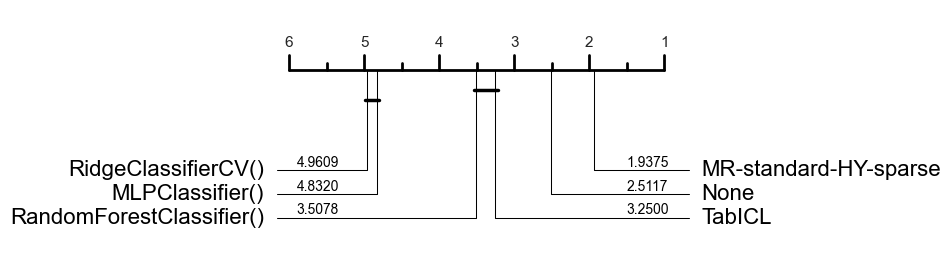

In [25]:
df = pl.read_parquet('QUANT/*.parquet')
df_matrix = df.pivot(
    index="dataset",
    columns="model",
    values="test_accuracy"
)

df_scaler = pl.read_parquet('scaler-combinations/*.parquet')
df_matrix_scaler = df_scaler.pivot(
    index="dataset",
    columns="model",
    values="test_accuracy"
)
model_name = "MR-standard-HY-sparse"

df_filtered = df_matrix_scaler.select([
    "dataset",
    model_name
])

df_joined = df_matrix.join(df_filtered, on="dataset", how="inner")
dfp = df_matrix.to_pandas().set_index("dataset")
scalers_used = list(df_joined.columns[1:])
accs = df_joined.select(scalers_used).to_numpy().tolist()
scalers_used[0] = "TabICL"
plot_critical_difference(accs, scalers_used)